In [16]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 8.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.8/562.8 kB 8.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 9.9 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 11.2 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 11.3 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [shap]6/7 [shap]st]]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.4.4 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.16.2 which is incompatible.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import shap

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42

In [18]:
df = pd.read_csv('melb_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (13580, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [19]:
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum().sort_values(ascending=False))

Suburb            object
Address           object
Rooms              int64
Type              object
Price            float64
Method            object
SellerG           object
Date              object
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea       object
Lattitude        float64
Longtitude       float64
Regionname        object
Propertycount    float64
dtype: object

Missing values:
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Car                62
Suburb              0
Bathroom            0
Regionname          0
Longtitude          0
Lattitude           0
Landsize            0
Bedroom2            0
Address             0
Postcode            0
Distance            0
Date                0
SellerG             0
Method              0
Price               0
Type                0
Rooms               0
Prop

In [20]:
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


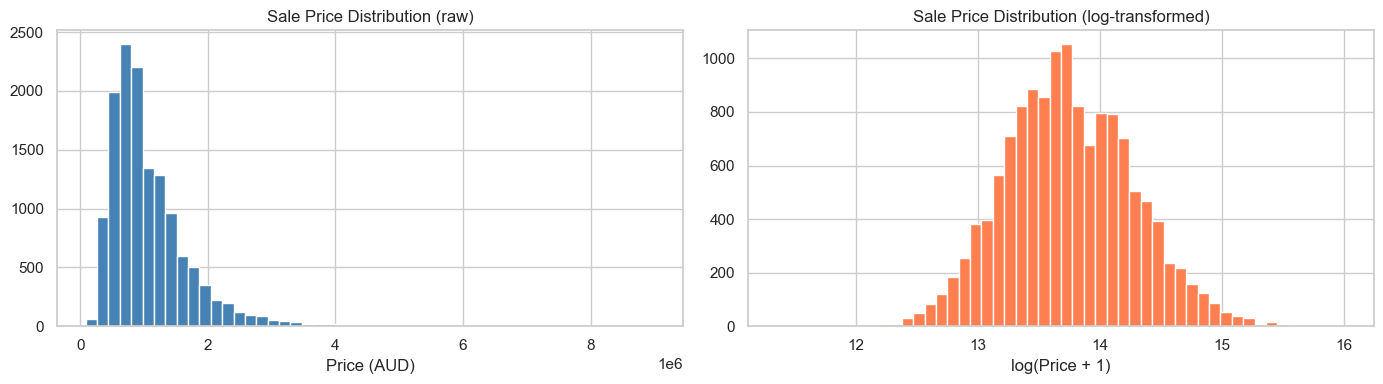

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Price'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sale Price Distribution (raw)')
axes[0].set_xlabel('Price (AUD)')

axes[1].hist(np.log1p(df['Price'].dropna()), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Sale Price Distribution (log-transformed)')
axes[1].set_xlabel('log(Price + 1)')

plt.tight_layout()
plt.show()

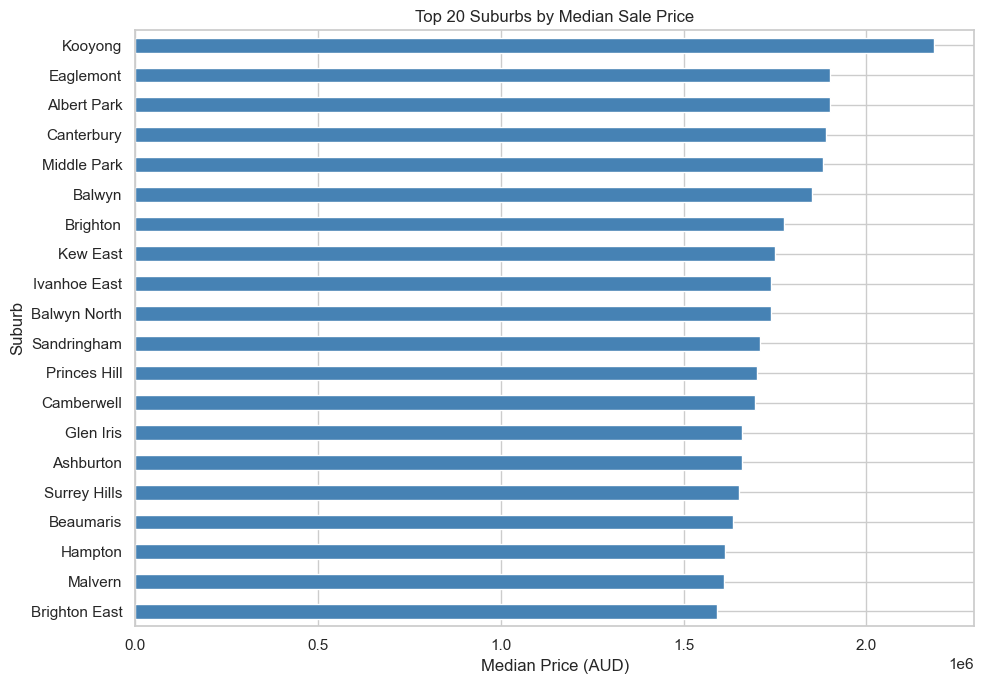

In [22]:
top_suburbs = (
    df.groupby('Suburb')['Price']
    .median()
    .sort_values(ascending=False)
    .head(20)
)

top_suburbs.plot(kind='barh', color='steelblue', figsize=(10, 7))
plt.title('Top 20 Suburbs by Median Sale Price')
plt.xlabel('Median Price (AUD)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

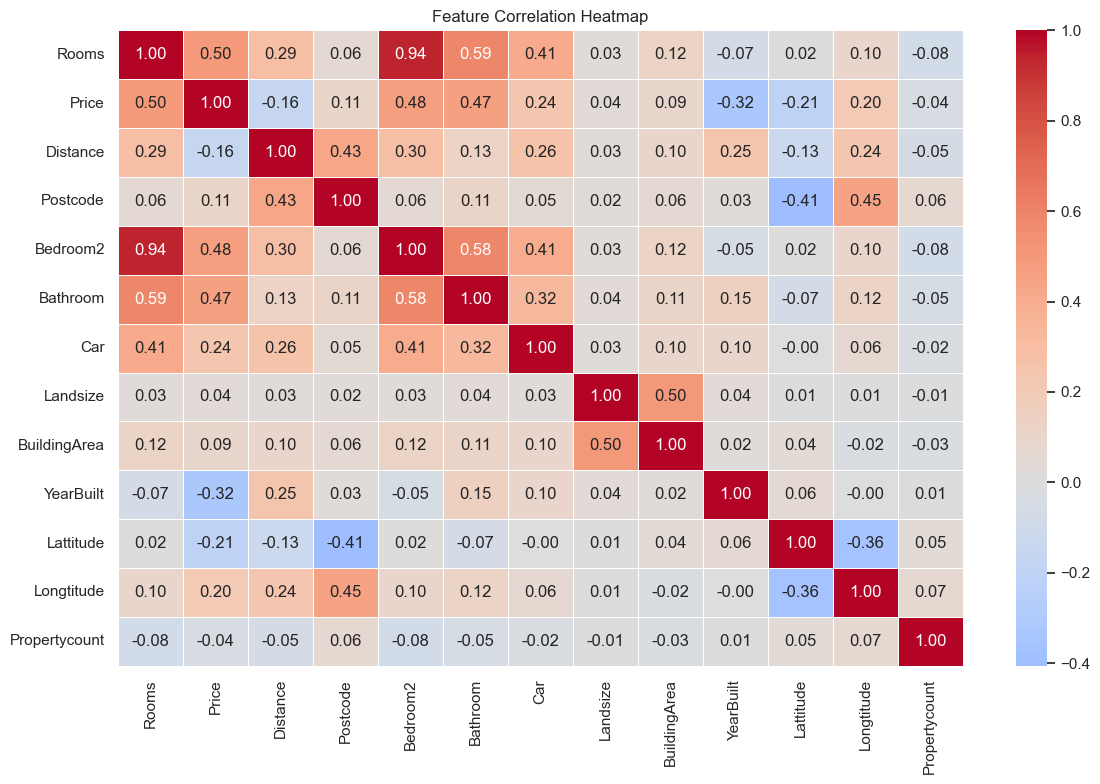

In [23]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [24]:
# Drop rows with no target value
df = df.dropna(subset=['Price'])

# Feature: age of property at time of sale
df['YearSold'] = pd.to_datetime(df['Date'], dayfirst=True).dt.year
df['PropertyAge'] = df['YearSold'] - df['YearBuilt']
df['PropertyAge'] = df['PropertyAge'].clip(lower=0)  # remove negative ages

# Log-transform the target to reduce skew
df['LogPrice'] = np.log1p(df['Price'])

print('New features added: YearSold, PropertyAge, LogPrice')
df[['YearBuilt', 'YearSold', 'PropertyAge', 'Price', 'LogPrice']].head()

New features added: YearSold, PropertyAge, LogPrice


,YearBuilt,YearSold,PropertyAge,Price,LogPrice
0,NaN,2016,NaN,1480000.0,14.207553
1,1900.0,2016,116.0,1035000.0,13.849913
2,1900.0,2017,117.0,1465000.0,14.197366
3,NaN,2017,NaN,850000.0,13.652993
4,2014.0,2016,2.0,1600000.0,14.285515


In [25]:
# Select features for modelling
FEATURES = [
    'Rooms', 'Type', 'Distance', 'Bathroom', 'Car',
    'Landsize', 'BuildingArea', 'PropertyAge', 'Regionname'
]
TARGET = 'LogPrice'

df_model = df[FEATURES + [TARGET]].copy()
print(f'Modelling dataset shape: {df_model.shape}')
df_model.isnull().sum()

Modelling dataset shape: (13580, 10)


Rooms              0
Type               0
Distance           0
Bathroom           0
Car               62
Landsize           0
BuildingArea    6450
PropertyAge     5375
Regionname         0
LogPrice           0
dtype: int64

In [26]:
# Define numeric and categorical columns
NUM_FEATURES = ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'PropertyAge']
CAT_FEATURES = ['Type', 'Regionname']

X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (10864, 9), Test: (2716, 9)


In [27]:
# Shared preprocessing transformer
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUM_FEATURES),
    ('cat', categorical_transformer, CAT_FEATURES)
])

In [28]:
# Define the three models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    'XGBoost':           XGBRegressor(n_estimators=300, learning_rate=0.05,
                                       max_depth=6, random_state=RANDOM_STATE,
                                       verbosity=0)
}

results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    # Inverse log transform for interpretable metrics
    preds_price    = np.expm1(preds)
    y_test_price   = np.expm1(y_test)

    rmse = np.sqrt(mean_squared_error(y_test_price, preds_price))
    mae  = mean_absolute_error(y_test_price, preds_price)
    r2   = r2_score(y_test, preds)  # R² on log scale

    results[name] = {'Pipeline': pipe, 'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f'{name:20s} | RMSE: ${rmse:>10,.0f} | MAE: ${mae:>10,.0f} | R²: {r2:.4f}')

Linear Regression    | RMSE: $ 1,421,935 | MAE: $   270,255 | R²: 0.6815
Random Forest        | RMSE: $   299,230 | MAE: $   181,797 | R²: 0.8310
XGBoost              | RMSE: $   281,112 | MAE: $   172,521 | R²: 0.8528


In [29]:
# Summary table
summary = pd.DataFrame({
    name: {'RMSE (AUD)': f"${v['RMSE']:,.0f}", 'MAE (AUD)': f"${v['MAE']:,.0f}", 'R²': f"{v['R2']:.4f}"}
    for name, v in results.items()
}).T
summary

,RMSE (AUD),MAE (AUD),R²
Linear Regression,"$1,421,935","$270,255",0.6815
Random Forest,"$299,230","$181,797",0.8310
XGBoost,"$281,112","$172,521",0.8528


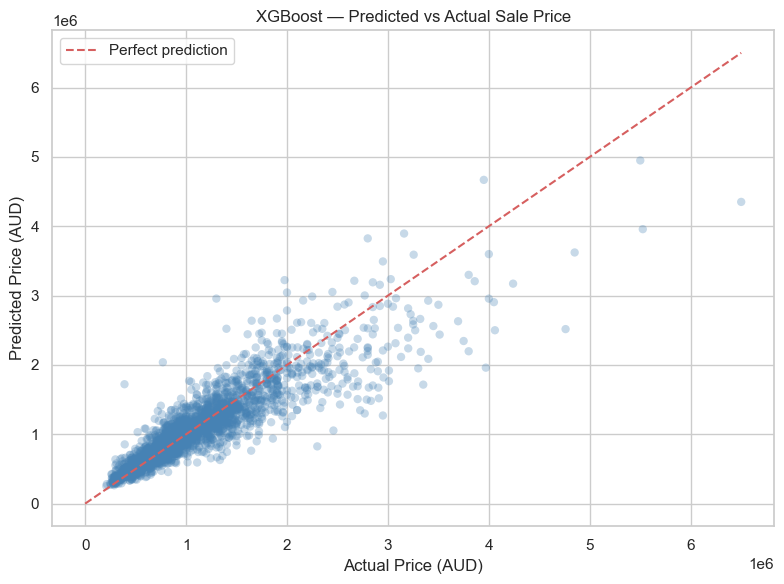

In [30]:
# Predicted vs Actual for best model (XGBoost)
best_pipe = results['XGBoost']['Pipeline']
preds_best = np.expm1(best_pipe.predict(X_test))
y_test_price = np.expm1(y_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_price, preds_best, alpha=0.3, color='steelblue', edgecolors='none')
max_val = max(y_test_price.max(), preds_best.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Price (AUD)')
plt.ylabel('Predicted Price (AUD)')
plt.title('XGBoost — Predicted vs Actual Sale Price')
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# Extract the preprocessed test set and XGBoost model
xgb_model   = best_pipe.named_steps['model']
X_test_proc = best_pipe.named_steps['preprocessor'].transform(X_test)

# Get feature names after one-hot encoding
ohe_features = best_pipe.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['encoder'] \
    .get_feature_names_out(CAT_FEATURES).tolist()
feature_names = NUM_FEATURES + ohe_features

# Compute SHAP values
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_proc)

print('SHAP values computed successfully.')

SHAP values computed successfully.


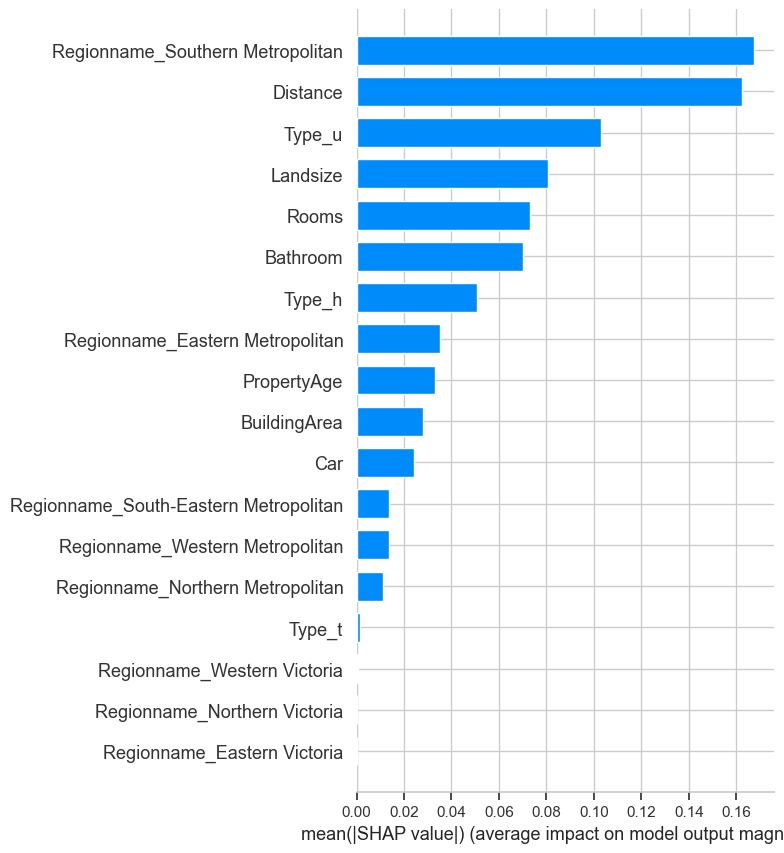

In [32]:
# Global feature importance summary plot
shap.summary_plot(shap_values, X_test_proc, feature_names=feature_names, plot_type='bar')

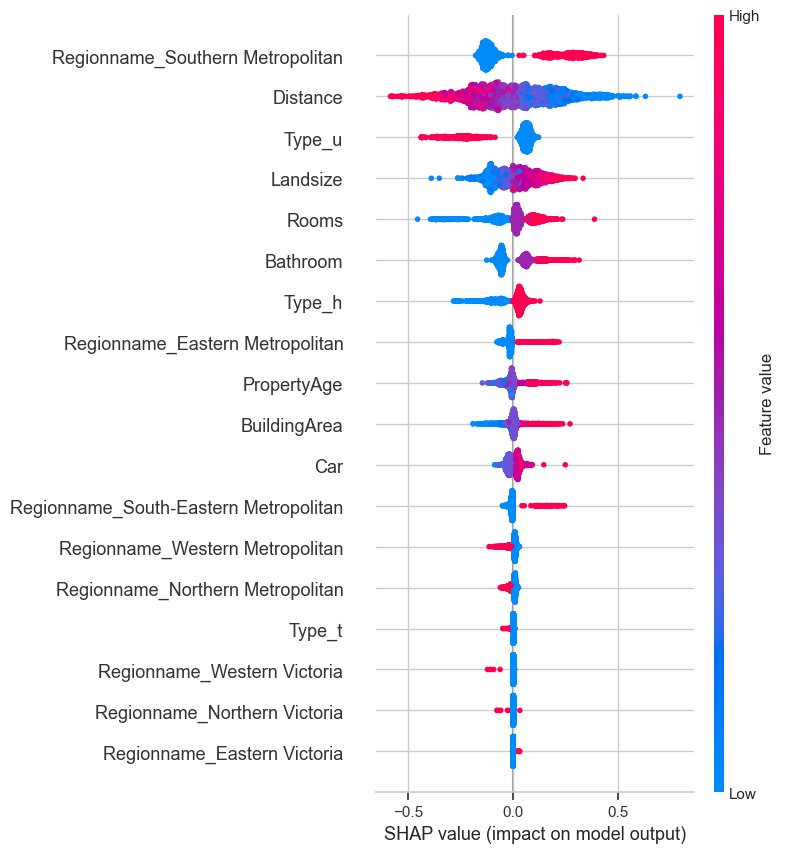

In [33]:
# Beeswarm plot — shows direction and magnitude of each feature's impact
shap.summary_plot(shap_values, X_test_proc, feature_names=feature_names)

In [34]:
# Explain a single prediction (first test sample)
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_proc[0],
    feature_names=feature_names
)

## 6. Key Findings

> **Fill this section in after running the notebook.**

- Best model: **XGBoost** with R² of 0.8528, RMSE of $281,112
- Most important features (from SHAP): `Distance`, `Rooms`, `BuildingArea`